In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sns

# Load the data
data = pd.read_csv("dataset.csv")

# Filtering columns
location_data = data[['location:log_latitude_range', 'location:log_longitude_range']]

# Drop rows with NaN values in the location data
location_data = location_data.dropna()

# Ensure these columns are numeric
location_data = location_data.astype(float)

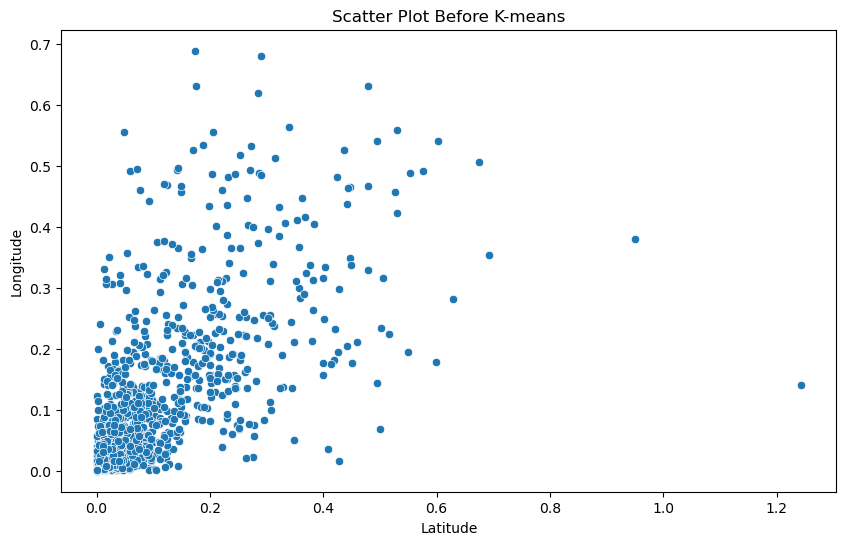

In [ ]:
# Plotting the scatter plot before K-means
plt.figure(figsize=(10, 6))
sns.scatterplot(data=location_data, x='location:log_latitude_range', y='location:log_longitude_range')
plt.title('Scatter Plot Before K-means')
plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.show()

In [ ]:
# Create the K-means model with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
location_data['cluster'] = kmeans.fit_predict(location_data)

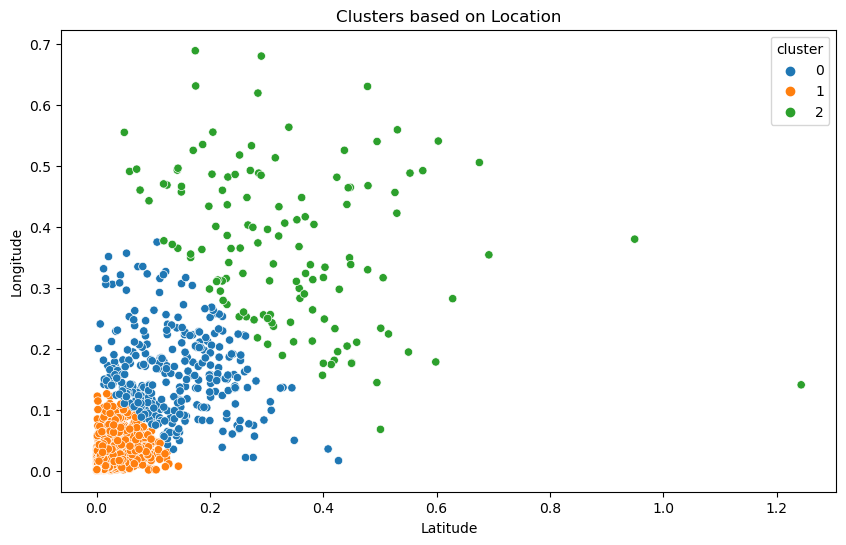

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=location_data, x='location:log_latitude_range', y='location:log_longitude_range', hue='cluster', palette='tab10')
plt.title('Clusters based on Location')
plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.show()

No activity data found for Cluster nan


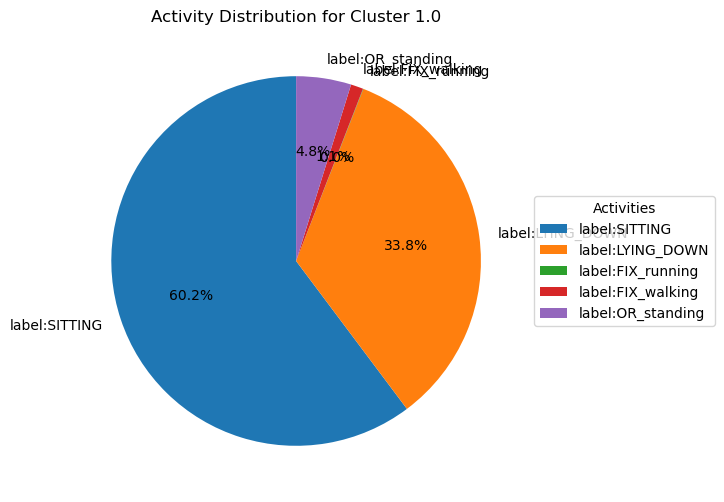

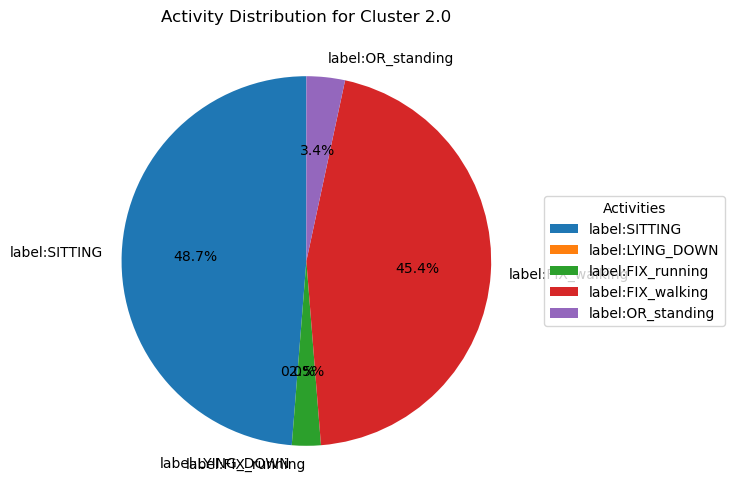

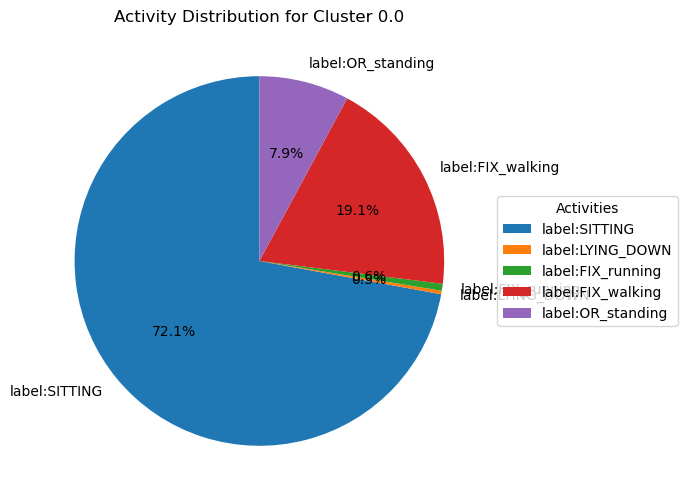

In [ ]:
import matplotlib.pyplot as plt

# List of activity columns
activities_of_interest = [
    'label:SITTING',
    'label:LYING_DOWN',
    'label:FIX_running',
    'label:FIX_walking',
    'label:OR_standing'
]

# Create pie charts for each cluster
for cluster in data_with_clusters['cluster'].unique():
    cluster_data = data_with_clusters[data_with_clusters['cluster'] == cluster]

    # Count occurrences of each activity of interest
    activity_counts = cluster_data[activities_of_interest].sum()

    # Convert counts to percentages
    total_activities = activity_counts.sum()

    if total_activities > 0:
        activity_percentages = (activity_counts / total_activities) * 100

        # Create pie chart
        plt.figure(figsize=(6, 6))
        wedges, texts, autotexts = plt.pie(
            activity_percentages,
            labels=activity_percentages.index,
            autopct='%1.1f%%',
            startangle=90
        )

        plt.legend(
            wedges,
            activity_percentages.index,
            title="Activities",
            loc="center left",
            bbox_to_anchor=(1, 0, 0.5, 1)
        )

        plt.title(f'Activity Distribution for Cluster {cluster}')
        plt.show()
    else:
        print(f"No activity data found for Cluster {cluster}")
